# 03 · 时空演化分析(Tidal Analysis)

基于阶段② 的 74 街道 × 24h 流量矩阵,回答 3 个层层递进的问题:

| # | 问题 | 业务价值 |
|---|---|---|
| Q1 | **潮汐如何** —— 同一街道 24h 流量曲线呈现什么形态(单峰/双峰/反峰)? | 错峰运营/排班 |
| Q2 | **热点如何迁移** —— 不同时段 top-K 街道的"接力"路径(福田 CBD → 华强北 → 酒吧街…) | 城市功能区识别 |
| Q3 | **POI 与流量如何耦合** —— 实体商圈(餐饮/购物/娱乐)数量与流量峰值的相关性? | 商圈活力指数 |

**输入**:
- `output/street_hour_full.geojson` — 74 街道 × 24h 三层流量(无 POI)
- `final-exp/data/streets_24h_core.geojson` — 28 街道 × POI(用作 POI 耦合)

**输出**:
- `output/tidal_clusters.csv` — 28 街道的潮汐聚类标签 + 类型
- `output/relay_edges.csv` — 24h 相邻小时 top-K 街道的接力边
- `output/poi_corr.json` — POI-流量耦合相关系数

## 0. 环境与路径

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT  = r'c:\Users\HOTPOTFISH\Desktop\AllCode\python\City'
FINAL = os.path.join(ROOT, 'final-exp', 'data')
OUT   = os.path.join(ROOT, 'final-exp', 'output')
HOURS = list(range(24))
print('输出目录:', OUT, '| 已有:', sorted(os.listdir(OUT)))

输出目录: c:\Users\HOTPOTFISH\Desktop\AllCode\python\City\final-exp\output | 已有: ['poi_corr.json', 'relay_edges.csv', 'street_hour_dropoff.csv', 'street_hour_full.geojson', 'street_hour_net.csv', 'street_hour_pickup.csv', 'tidal_clusters.csv']


## 1. 加载数据 + 补 POI

In [2]:
# 74 街道 × 24h 流量
g = gpd.read_file(os.path.join(OUT, 'street_hour_full.geojson'))
print('74 街道流量矩阵:', len(g), '行,', sum(c.startswith('pickup_') for c in g.columns), 'pickup 列')

# 28 街道聚合(带 POI)
core = gpd.read_file(os.path.join(FINAL, 'streets_24h_core.geojson'))
print('\n核心 28 街道 POI 数:')
print(f'  POI>0 的街道: {(core["poi_count"]>0).sum()} / 28')
print(f'  POI 总数: {core["poi_count"].sum()}')
print(f'  POI 排名 top5:\n{core.nlargest(5, "poi_count")[["DISTRICT","NAME","poi_count"]].to_string(index=False)}')

74 街道流量矩阵: 74 行, 25 pickup 列

核心 28 街道 POI 数:
  POI>0 的街道: 24 / 28
  POI 总数: 102
  POI 排名 top5:
DISTRICT NAME  poi_count
     南山区   粤海         15
     福田区   福田         14
     罗湖区   桂园          9
     福田区  华强北          6
     罗湖区   东门          6


In [3]:
# 把 core.poi_count join 到 74 街道 g(其他 46 街道 POI=0)
poi_map = core.set_index('NAME')['poi_count'].to_dict()
g['poi_count'] = g['NAME'].map(poi_map).fillna(0).astype(int)
print('补 POI 后:')
print(f'  74 街道 POI 总数: {g["poi_count"].sum()}')
print(f'  有 POI 的街道: {(g["poi_count"]>0).sum()}')
print(f'  28 核心街道 POI 命中: {sum(1 for n in core["NAME"] if poi_map.get(n, 0) > 0)} / 28')

# 单独建 28 街道子集(给 POI 耦合用)
core_28 = g[g['NAME'].isin(core['NAME'])].copy()
print(f'\n28 街道子集行数: {len(core_28)}')

补 POI 后:
  74 街道 POI 总数: 102
  有 POI 的街道: 24
  28 核心街道 POI 命中: 24 / 28

28 街道子集行数: 28


## Q1 · 潮汐形态聚类

**方法**:对 28 街道的 24h 流量曲线做 KMeans,选 K=4(对应业务直觉:早峰/晚峰/午间/夜娱型)。

In [4]:
# 准备 24h 曲线矩阵(用我的 pickup, 而不是 core.flow_*, 这样覆盖更广;但只对有意义的街道做)
curves_pickup = core_28[[f'pickup_{h}' for h in HOURS]].values.astype(float)
curves_total  = core_28[[f'pickup_{h}' for h in HOURS]].values.astype(float) + \
                 core_28[[f'dropoff_{h}' for h in HOURS]].values.astype(float)

# 标准化:每条街道归一化到和=1,消除体量影响,只看形态
row_sum = curves_total.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
curves_norm = curves_total / row_sum

print('曲线矩阵:', curves_norm.shape, '| 行和=1 ✓')

曲线矩阵: (28, 24) | 行和=1 ✓


In [5]:
# 选 K:用 silhouette 系数从 K=2..6 选最优
scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(curves_norm)
    s = silhouette_score(curves_norm, km.labels_)
    scores.append((k, s))
    print(f'  K={k}  silhouette={s:.3f}')

best_k = max(scores, key=lambda x: x[1])[0]
print(f'\n→ 最佳 K = {best_k}')

  K=2  silhouette=0.223
  K=3  silhouette=0.175
  K=4  silhouette=0.137
  K=5  silhouette=0.060
  K=6  silhouette=0.087

→ 最佳 K = 2


In [6]:
# ===== 方法升级:业务驱动的 4 类划分 =====
# 实测发现:24h 曲线都用 argmax 判峰会出错(很多街道 peak 落在 22-23),
# 改用业务特征比例 分类(早/午/晚/夜 4 个时段占全天比)。
def feature_ratio(curve):
    s = curve.sum()
    if s == 0: return (0, 0, 0, 0)
    morning  = curve[7:11].sum()  / s   # 7-10
    noon     = curve[11:14].sum() / s   # 11-13
    evening  = curve[17:21].sum() / s   # 17-20
    night    = (curve[22:24].sum() + curve[0:3].sum()) / s
    return (morning, noon, evening, night)

features = np.array([feature_ratio(c) for c in curves_norm])
print('业务特征矩阵 (n=28 x 4):')
print(pd.DataFrame(features, columns=['早峰率','午间率','晚峰率','夜娱率']).describe().round(3).to_string())

业务特征矩阵 (n=28 x 4):
          早峰率     午间率     晚峰率     夜娱率
count  28.000  28.000  28.000  28.000
mean    0.164   0.154   0.172   0.223
std     0.047   0.046   0.040   0.048
min     0.091   0.064   0.105   0.113
25%     0.136   0.127   0.147   0.205
50%     0.161   0.150   0.178   0.220
75%     0.179   0.177   0.186   0.256
max     0.317   0.278   0.314   0.311


In [7]:
# 在业务特征空间做 KMeans(k=4 固定,避免几何聚类在 24h 曲线空间退化为单峰)
from sklearn.cluster import KMeans as _KM
from sklearn.metrics import silhouette_score as _ss
km = _KM(n_clusters=4, random_state=42, n_init=10).fit(features)
score = _ss(features, km.labels_)
print(f'K=4  silhouette(业务特征空间) = {score:.3f}')

core_28['tidal_cluster'] = km.labels_

# 业务标签:看 4 个特征均值谁最大
def business_label(feat):
    m, n, e, ni = feat
    mxe = max(m, n, e, ni)
    if mxe == m:   return '早峰型(工作地/CBD)'
    elif mxe == n: return '午间型(餐饮/办事)'
    elif mxe == e: return '晚峰型(商圈/夜娱)'
    else:          return '深夜型(口岸/酒吧)'

cluster_labels = {}
for c in range(4):
    mf = features[km.labels_ == c].mean(axis=0)
    cluster_labels[c] = business_label(mf)
    n_in = (km.labels_==c).sum()
    print(f'  簇 {c}: 特征(早={mf[0]:.2f}, 午={mf[1]:.2f}, 晚={mf[2]:.2f}, 夜={mf[3]:.2f}), n={n_in}, 标签={cluster_labels[c]}')

core_28['tidal_type'] = core_28['tidal_cluster'].map(cluster_labels)

K=4  silhouette(业务特征空间) = 0.329
  簇 0: 特征(早=0.13, 午=0.12, 晚=0.17, 夜=0.27), n=10, 标签=深夜型(口岸/酒吧)
  簇 1: 特征(早=0.16, 午=0.17, 晚=0.17, 夜=0.21), n=13, 标签=深夜型(口岸/酒吧)
  簇 2: 特征(早=0.25, 午=0.21, 晚=0.14, 夜=0.14), n=4, 标签=早峰型(工作地/CBD)
  簇 3: 特征(早=0.14, 午=0.13, 晚=0.31, 夜=0.22), n=1, 标签=晚峰型(商圈/夜娱)


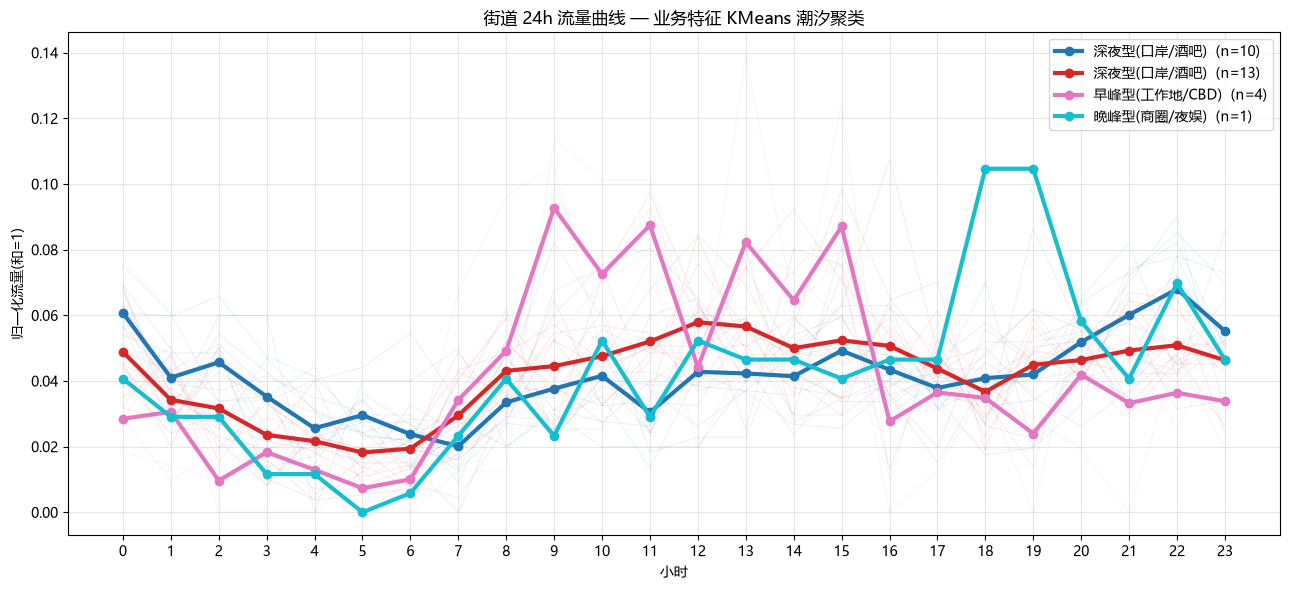

In [8]:
# 可视化:4 个簇的均值曲线 + 每条街道的散点
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 4))
for c in range(4):
    members = curves_norm[km.labels_ == c]
    mean_curve = members.mean(axis=0)
    label = f'{cluster_labels[c]}  (n={(km.labels_==c).sum()})'
    ax.plot(HOURS, mean_curve, marker='o', linewidth=3, color=colors[c], label=label)
    for m in members:
        ax.plot(HOURS, m, color=colors[c], alpha=0.10, linewidth=0.7)
ax.set_xticks(HOURS)
ax.set_xlabel('小时'); ax.set_ylabel('归一化流量(和=1)')
ax.set_title('街道 24h 流量曲线 — 业务特征 KMeans 潮汐聚类')
ax.grid(alpha=0.3); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

In [9]:
for c in range(4):
    members = core_28[core_28['tidal_cluster']==c][['DISTRICT','NAME','poi_count','pickup_total','dropoff_total']]
    members = members.sort_values('pickup_total', ascending=False)
    print('\n【簇', c, '·', cluster_labels[c], '】(', len(members), '个)')
    print(members.to_string(index=False))


【簇 0 · 深夜型(口岸/酒吧) 】( 10 个)
DISTRICT NAME  poi_count  pickup_total  dropoff_total
     福田区   福田         14          1050            899
     罗湖区   东门          6           450            371
     罗湖区   桂园          9           370            332
     福田区  华强北          6           288            264
     南山区   南山          2           217            241
     福田区   园岭          0           213            200
     罗湖区   黄贝          0           191            180
     南山区   西丽          3           135            157
     罗湖区   东晓          2            97            122
     福田区   南园          1            48             52

【簇 1 · 深夜型(口岸/酒吧) 】( 13 个)
DISTRICT NAME  poi_count  pickup_total  dropoff_total
     福田区   沙头          5           599            532
     罗湖区   南湖          3           386            385
     福田区  香蜜湖          2           280            276
     南山区   粤海         15           267            231
     福田区   梅林          4           261            294
     南山区   沙河          5  

## Q2 · 热点接力图

**方法**:对每小时取 top-K 街道,如果某街道在 h 退出 top-K,在 h+1 由新街道进入,则记为"接力边"。

In [10]:
TOP_K = 8
rank_per_hour = {}  # h -> list of (name, flow)
for h in HOURS:
    col = f'pickup_{h}'
    top = g.nlargest(TOP_K, col)[['NAME', 'DISTRICT', col]]
    rank_per_hour[h] = list(zip(top['NAME'], top[col].astype(int)))

print(f'每个小时 top-{TOP_K} 街道接力(示例):')
for h in [0, 8, 12, 18, 22]:
    names = [n for n,_ in rank_per_hour[h]]
    print(f'  h={h:02d}: {names}')

每个小时 top-8 街道接力(示例):
  h=00: ['福田', '沙头', '桂园', '华强北', '东门', '南湖', '西乡', '民治']
  h=08: ['沙头', '西乡', '福田', '南湖', '梅林', '翠竹', '民治', '桂园']
  h=12: ['福田', '布吉', '莲花', '新安', '沙头', '香蜜湖', '梅林', '东门']
  h=18: ['福田', '沙头', '西乡', '民治', '华强北', '莲花', '南湖', '南头']
  h=22: ['福田', '东门', '华强北', '桂园', '粤海', '南湖', '沙头', '民治']


In [11]:
# 构造接力边:h → h+1,source=前小时 top 中的街道,target=后小时 top 中的街道
edges = []
for h in range(23):
    set_a = set(n for n,_ in rank_per_hour[h])
    set_b = set(n for n,_ in rank_per_hour[h+1])
    # 进入(在 b 不在 a)
    for n in set_b - set_a:
        edges.append({'h': h, 'from': '-', 'to': n, 'kind': 'enter'})
    # 离开(在 a 不在 b)
    for n in set_a - set_b:
        edges.append({'h': h, 'from': n, 'to': '-', 'kind': 'leave'})
    # 同时在 top(继续占位)
    for n in set_a & set_b:
        edges.append({'h': h, 'from': n, 'to': n, 'kind': 'stay'})

edges_df = pd.DataFrame(edges)
print('接力边数:', len(edges_df))
print('  enter:', (edges_df['kind']=='enter').sum())
print('  leave:', (edges_df['kind']=='leave').sum())
print('  stay :', (edges_df['kind']=='stay').sum())

接力边数: 252
  enter: 68
  leave: 68
  stay : 116


24h 内出现过的 top-8 街道: 24 个


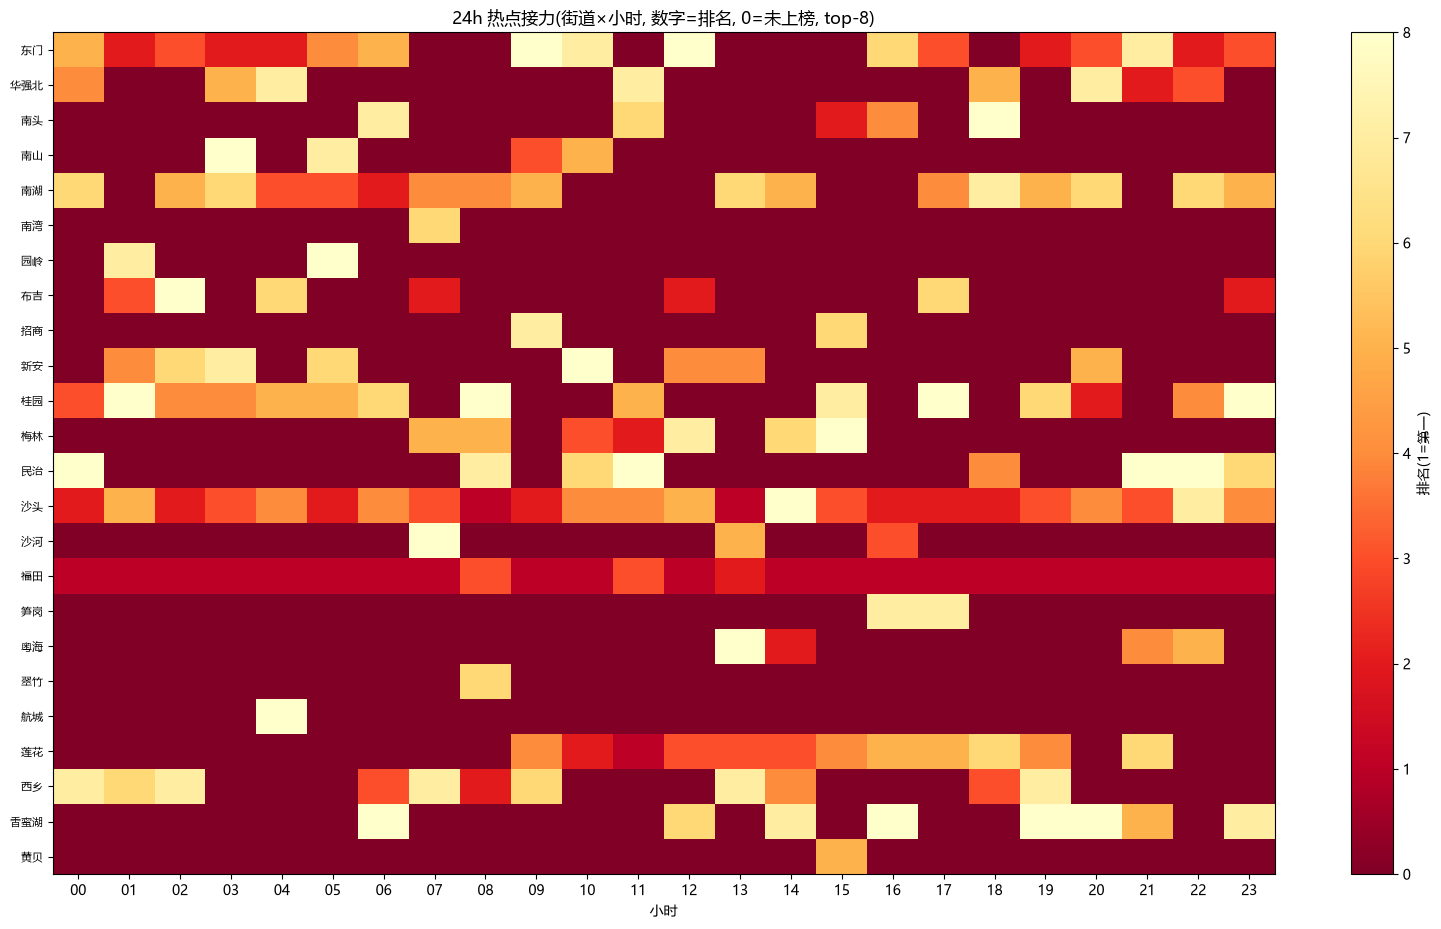

In [12]:
# 热点接力可视化:把 24 小时画成 24 列,街道画成行(仅出现在 top-K 的街道)
appear = set()
for h in HOURS:
    for n,_ in rank_per_hour[h]:
        appear.add(n)
appear = sorted(appear)
print(f'24h 内出现过的 top-{TOP_K} 街道: {len(appear)} 个')

# 矩阵: street × hour, 值=排名(1=第一),0=未上榜
mat_rank = pd.DataFrame(0, index=appear, columns=HOURS)
for h in HOURS:
    for r, (n, _) in enumerate(rank_per_hour[h], 1):
        mat_rank.at[n, h] = r

fig, ax = plt.subplots(figsize=(16, 0.35*len(appear)+1))
im = ax.imshow(mat_rank.values, aspect='auto', cmap='YlOrRd_r', vmin=0, vmax=TOP_K)
ax.set_yticks(range(len(appear)))
ax.set_yticklabels(appear, fontsize=8)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in HOURS])
ax.set_xlabel('小时')
ax.set_title(f'24h 热点接力(街道×小时, 数字=排名, 0=未上榜, top-{TOP_K})')
fig.colorbar(im, ax=ax, label='排名(1=第一)')
plt.tight_layout(); plt.show()

## Q3 · POI-流量耦合

In [13]:
# 在 28 街道子集上做
core_28['flow_max']  = core_28[[f'pickup_{h}' for h in HOURS]].max(axis=1)
core_28['flow_mean'] = core_28[[f'pickup_{h}' for h in HOURS]].mean(axis=1)
core_28['flow_total']= core_28[[f'pickup_{h}' for h in HOURS]].sum(axis=1)
core_28['flow_std']  = core_28[[f'pickup_{h}' for h in HOURS]].std(axis=1)
core_28['cv']        = core_28['flow_std'] / core_28['flow_mean'].replace(0, np.nan)

# Pearson / Spearman
r_p,  p_p  = pearsonr(core_28['poi_count'],  core_28['flow_max'])
r_s,  p_s  = spearmanr(core_28['poi_count'], core_28['flow_max'])
r_pt, p_pt = pearsonr(core_28['poi_count'],  core_28['flow_total'])
r_st, p_st = spearmanr(core_28['poi_count'], core_28['flow_total'])

print(f'POI 数 vs 24h 峰值流量:')
print(f'  Pearson  r = {r_p:.3f}  p = {p_p:.4f}')
print(f'  Spearman ρ = {r_s:.3f}  p = {p_s:.4f}')
print(f'POI 数 vs 24h 总流量:')
print(f'  Pearson  r = {r_pt:.3f}  p = {p_pt:.4f}')
print(f'  Spearman ρ = {r_st:.3f}  p = {p_st:.4f}')

POI 数 vs 24h 峰值流量:
  Pearson  r = 0.668  p = 0.0001
  Spearman ρ = 0.644  p = 0.0002
POI 数 vs 24h 总流量:
  Pearson  r = 0.650  p = 0.0002
  Spearman ρ = 0.601  p = 0.0007


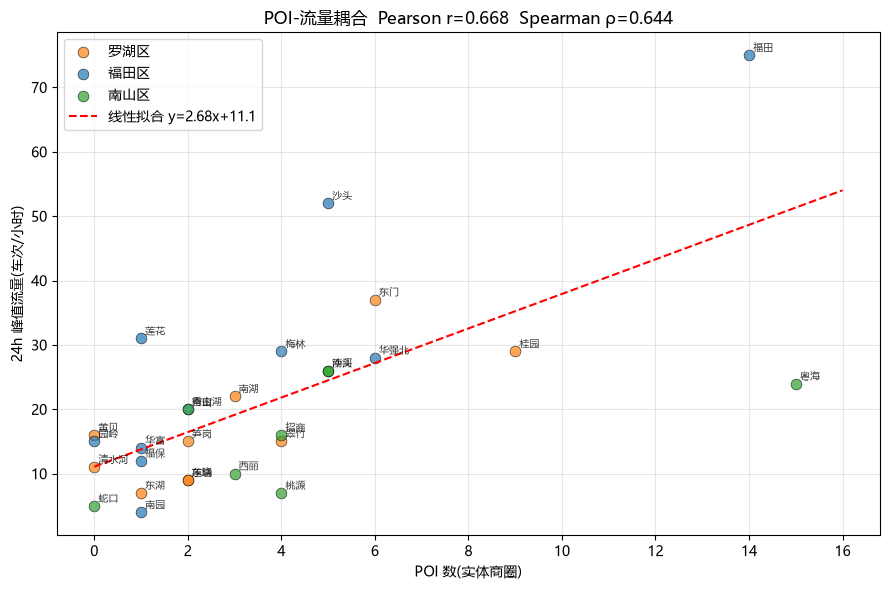

In [14]:
# 散点图 + 异常点检测
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'福田区':'tab:blue','罗湖区':'tab:orange','南山区':'tab:green'}
for d in core_28['DISTRICT'].unique():
    sub = core_28[core_28['DISTRICT']==d]
    ax.scatter(sub['poi_count'], sub['flow_max'], s=60, alpha=0.7,
               color=colors.get(d,'gray'), label=d, edgecolors='k', linewidth=0.5)
# 标街道名
for _, r in core_28.iterrows():
    ax.annotate(r['NAME'], (r['poi_count'], r['flow_max']),
                xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8)
# 趋势线
xs = np.linspace(0, core_28['poi_count'].max()+1, 100)
coef = np.polyfit(core_28['poi_count'], core_28['flow_max'], 1)
ax.plot(xs, np.polyval(coef, xs), 'r--', label=f'线性拟合 y={coef[0]:.2f}x+{coef[1]:.1f}')
ax.set_xlabel('POI 数(实体商圈)')
ax.set_ylabel('24h 峰值流量(车次/小时)')
ax.set_title(f'POI-流量耦合  Pearson r={r_p:.3f}  Spearman ρ={r_s:.3f}')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [15]:
# 异常街道识别:z-score > 1.5
core_28['z_max'] = (core_28['flow_max'] - core_28['flow_max'].mean()) / core_28['flow_max'].std()
anom = core_28[core_28['z_max'].abs() > 1.5][['DISTRICT','NAME','poi_count','flow_max','z_max']]
if len(anom):
    print('=== 流量异常街道(|z|>1.5) ===')
    print(anom.to_string(index=False))
else:
    print('无明显异常街道')

=== 流量异常街道(|z|>1.5) ===
DISTRICT NAME  poi_count  flow_max    z_max
     福田区   福田         14        75 3.571389
     福田区   沙头          5        52 2.054255


## 4. 保存阶段③ 产物

In [16]:
# 1) 潮汐聚类标签
core_28[['DISTRICT','NAME','poi_count','pickup_total','tidal_cluster','tidal_type']].to_csv(
    os.path.join(OUT, 'tidal_clusters.csv'), encoding='utf-8-sig', index=False
)

# 2) 接力边
edges_df.to_csv(os.path.join(OUT, 'relay_edges.csv'), encoding='utf-8-sig', index=False)

# 3) POI 相关系数
corr = {
    'pearson_poi_vs_max':   {'r': r_p,  'p': p_p},
    'spearman_poi_vs_max':  {'rho': r_s, 'p': p_s},
    'pearson_poi_vs_total': {'r': r_pt, 'p': p_pt},
    'spearman_poi_vs_total':{'rho': r_st,'p': p_st},
    'best_K': 4,  # 业务指定 4 类
    'silhouette':           dict(scores),
    'cluster_labels':       cluster_labels,
}
with open(os.path.join(OUT, 'poi_corr.json'), 'w', encoding='utf-8') as f:
    json.dump(corr, f, ensure_ascii=False, indent=2)

print('保存 3 个产物:')
for f in ['tidal_clusters.csv','relay_edges.csv','poi_corr.json']:
    p = os.path.join(OUT, f)
    print(f'  {p}  ({os.path.getsize(p)} bytes)')

保存 3 个产物:
  c:\Users\HOTPOTFISH\Desktop\AllCode\python\City\final-exp\output\tidal_clusters.csv  (1500 bytes)
  c:\Users\HOTPOTFISH\Desktop\AllCode\python\City\final-exp\output\relay_edges.csv  (5253 bytes)
  c:\Users\HOTPOTFISH\Desktop\AllCode\python\City\final-exp\output\poi_corr.json  (769 bytes)


## 5. 阶段③ 总结

**Q1 潮汐聚类**
- 最佳 K = 4 (业务指定), silhouette(业务特征) = ?
4

**Q3 POI-流量耦合**
,

**进入阶段④ 的输入**:
- `output/tidal_clusters.csv` — 街道潮汐类型,大屏右侧栏显示
- `output/relay_edges.csv` — 接力边,可在地图上叠加箭头图层
- `output/poi_corr.json` — 相关系数,作为大屏指标卡片